#修了課題①　Titanic

利用するデータセット：タイタニック号の搭乗者データ

合格基準：テストデータに対して正解率80%以上

データセットの中身

*   pclass： 旅客クラス（1＝1等、2＝2等、3＝3等）。(裕福さの目安)
*   name： 乗客の名前
*   sex： 性別（male＝男性、female＝女性）
*   age： 年齢。一部の乳児は小数値
*   sibsp： タイタニック号に同乗している兄弟（Siblings）や配偶者（Spouses）の数
*   parch： タイタニック号に同乗している親（Parents）や子供（Children）の数
*   ticket： チケット番号
*   fare： 旅客運賃
*   cabin： 客室番号
*   embarked： 出港地（C＝Cherbourg：シェルブール、Q＝Queenstown：クイーンズタウン、S＝Southampton：サウサンプトン）
*   boat： 救命ボート番号
*   body： 遺体収容時の識別番号
*   home.dest： 自宅または目的地



# データのダウンロード
※変更しない様、お願いいたします。

In [1]:
import pandas as pd
import numpy as np

In [2]:

# 学習用のデータのダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ' -O titanic_train.csv
# 検証用のデータのダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1jmzmYNPRWUGLcHeqhcwKTGlb_d2Rzn4Y' -O titanic_validation.csv

# 課題提出時に利用するデータのダウンロード
!wget 'https://drive.google.com/uc?export=download&id=1-1KX2NQmwUOXAstOE7c2INC1rRMNABVZ' -O titanic_test_x.csv

--2026-07-29 16:21:30--  https://drive.google.com/uc?export=download&id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ
Resolving drive.google.com (drive.google.com)... 142.251.170.101, 142.251.170.100, 142.251.170.113, ...
Connecting to drive.google.com (drive.google.com)|142.251.170.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ&export=download [following]
--2026-07-29 16:21:30--  https://drive.usercontent.google.com/download?id=1-12Pg5IsjNAEbgk7G4a2WqFaOhpYmbyJ&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.188.132, 2404:6800:4008:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.188.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68821 (67K) [application/octet-stream]
Saving to: ‘titanic_train.csv’

titanic_train.csv   100%[===================>]  67.21K  --.-

データ読み出し

欠損値はNaN埋め

In [3]:
# 学習用データ生成
train_df = pd.read_csv('titanic_train.csv', index_col=0)
train_df = train_df.replace('?', np.nan)

# 作業用コピー
train_cp = train_df.copy(deep=True)

# 検証用データ生成
val_df = pd.read_csv('titanic_validation.csv', index_col=0)
val_df = val_df.replace('?', np.nan)

# 作業用コピー
val_cp = val_df.copy(deep=True)


# 学習用データ分析

## 学習用データ分析

pclass と survived の関係分析

In [4]:
# クラス pclass との関係性
train_cp[['pclass', 'survived']].groupby(['pclass'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)

,pclass,count,survived
0,1,198,0.616162
1,2,172,0.453488
2,3,430,0.246512


関連性あり

age と survived の関係分析

In [5]:
# クラス age との関係

# 10才刻みにしてグルーピングする
df = train_cp.copy(deep=True)
df['age'] = df['age'].dropna()
df['age'] = df['age'].astype(float)/10
df['age'] = np.floor(df['age'])*10
df[['age', 'survived']].groupby(['age'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)

,age,count,survived
0,0.0,49,0.591837
5,50.0,42,0.452381
1,10.0,91,0.417582
3,30.0,138,0.398551
2,20.0,202,0.376238
4,40.0,83,0.373494
6,60.0,20,0.300000
7,70.0,5,0.200000


関連性はありそう

sibsp と survived の関係分析

In [6]:
# クラス sibsp
train_cp[['sibsp', 'survived']].groupby(['sibsp'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)


,sibsp,count,survived
1,1,186,0.505376
2,2,21,0.380952
0,0,557,0.359066
3,3,12,0.166667
4,4,15,0.133333
5,5,3,0.000000
6,8,6,0.000000


なんとなく関連はありそう

sex と survived の関係分析

In [7]:
# クラス sex
train_cp[['sex', 'survived']].groupby(['sex'], as_index=False).mean().sort_values(by='survived', ascending=False)

,sex,survived
0,female,0.707143
1,male,0.207692


関連あり

parch と survived の関係分析

In [8]:
# クラス parch
train_cp[['parch', 'survived']].groupby(['parch'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)


,parch,count,survived
1,1,101,0.554455
3,3,6,0.500000
2,2,67,0.447761
0,0,617,0.350081
4,4,3,0.333333
5,5,3,0.000000
6,6,2,0.000000
7,9,1,0.000000


関連なさそう

fare と survived の関係分析

In [9]:
# クラス fare
df = train_cp.copy(deep=True)
df['fare'] = df['fare'].dropna().astype(float)
df['fare'] = df['fare'].round(-1)

df[['fare', 'survived']].groupby(['fare'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)


,fare,count,survived
13,140.0,4,1.000000
12,130.0,2,1.000000
21,510.0,1,1.000000
11,120.0,3,1.000000
6,60.0,21,0.857143
10,110.0,7,0.857143
9,90.0,12,0.833333
8,80.0,24,0.750000
15,160.0,4,0.750000
20,260.0,7,0.714286


あまり関連なさそう


embarked と survived の関係分析

In [10]:
# クラス　embarked
df = train_cp.copy(deep=True)

# 欠損部を除く
df['embarked'] = df['embarked'].dropna()

train_cp[['embarked', 'survived']].groupby(['embarked'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)

,embarked,count,survived
0,C,166,0.572289
1,Q,77,0.376623
2,S,557,0.326750


関連ありそう

boat と survived の関係分析

In [11]:
# クラス boat
df = train_cp.copy(deep=True)
df['boat'] = df['boat'].dropna()
df[['boat', 'survived']].groupby(['boat'], as_index=False)['survived'].agg(count="count", survived="mean").sort_values('survived', ascending=False)


,boat,count,survived
0,1,4,1.000000
1,10,14,1.000000
2,11,16,1.000000
3,12,15,1.000000
4,13,21,1.000000
5,13 15,1,1.000000
6,13 15 B,1,1.000000
8,15,20,1.000000
9,15 16,1,1.000000
17,8,20,1.000000


関連性あり

ボードに乗れたら生存率が高まるということ

cabinは欠損値が多いので使わない

#モデルの制作

生存と関連ありそうな項目

*  pclass:旅客クラス
*  age:年齢
*  sex:性別
*  sibsp:同乗の兄弟
*  embarked:出向地
*  boat:ボート

欠損が多い、cabin、boatは削除。

これらを使って学習を行う

元データ確認

In [12]:
# 使用する列を抜き出し
colums = ['pclass', 'age', 'sex', 'sibsp', 'embarked', 'boat', 'survived']

train_cp = train_df[colums].copy()
val_cp = val_df[colums].copy()

train_cp.info()
val_cp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pclass    800 non-null    int64 
 1   age       630 non-null    object
 2   sex       800 non-null    object
 3   sibsp     800 non-null    int64 
 4   embarked  800 non-null    object
 5   boat      297 non-null    object
 6   survived  800 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 50.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 800 to 999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pclass    200 non-null    int64 
 1   age       169 non-null    object
 2   sex       200 non-null    object
 3   sibsp     200 non-null    int64 
 4   embarked  199 non-null    object
 5   boat      73 non-null     object
 6   survived  200 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 12.5+ KB


## データクレンジング処理

1. pclass,sex,sibspは欠損値がないので何もしなくてよい
2. ageの欠損値は平均年齢で埋める
3. embarkdは最頻値で埋めて、ラベルエンコーディング
4. boatはラベルエンコーディングする

In [13]:
# ageの欠損値に平均年齢を入れる
train_cp['age'] = train_cp['age'].astype(float)
ave_age = train_cp['age'].dropna().mean()

# 高速化のため int に変換
train_cp['age'] = train_cp['age'].fillna(ave_age).round(0).astype(int)

# 検証データも同様に処理
val_cp['age'] = val_cp['age'].astype(float)
# 高速化のため int に変換
val_cp['age'] = val_cp['age'].fillna(ave_age).round(0).astype(int)

In [14]:
# sexをエンコーディング
train_cp['sex'] = train_cp['sex'].map( {'female': 1, 'male': 0} ).astype(int)
val_cp['sex'] = val_cp['sex'].map( {'female': 1, 'male': 0} ).astype(int)

In [15]:
# embarkedの欠損値に最頻値を入れる
freq_port = train_cp['embarked'].mode()[0]
train_cp['embarked'] =train_cp['embarked'].fillna(freq_port)

# embarkedをエンコーディング
train_cp['embarked'] = train_cp['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

# 同じことを検証データにも実施
val_cp['embarked'] = val_cp['embarked'].fillna(freq_port)
val_cp['embarked'] = val_cp['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

In [16]:
# boatをラベルエンコーディング
boat = pd.concat([train_cp['boat'], val_cp['boat']], ignore_index=True)
boat_names = boat.unique()

boat_map = {
    value: code
    for code, value in enumerate(boat_names)
}

# boatをエンコーディング
train_cp['boat'] = train_cp['boat'].map(boat_map).astype(int)

# 同じことを検証データにも実施
val_cp['boat'] = val_cp['boat'].map(boat_map).astype(int)

# 学習

## データの分割

In [17]:
X_train = train_cp[['pclass', 'age', 'sex', 'sibsp', 'embarked', 'boat']]
y_train = train_cp['survived']
X_val = val_cp[['pclass', 'age', 'sex', 'sibsp', 'embarked', 'boat']]
y_val = val_cp['survived']

# モデルの構築

## NNの構築

損失関数、活性化関数、ニューラルネットワークを構築

損失関数はMSE、活性化関数はシグモイド関数

ネットワークは2層のニューラルネットワーク



In [18]:
# バッチ版mse
def rmse(y, t):
    delta = 1e-7
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    mini_batch = y.shape[0]
    t = t.astype(int)
    return np.sqrt(np.sum((y - t)**2) / mini_batch)

# 活性化関数
# シグモイド関数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    return (1 - sigmoid(x)) * sigmoid(x)


In [19]:
import numpy as np

# 2層のニューラルネットワーク
class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):

        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        # forward
        u1 = np.dot(x, W1) + b1
        z1 = sigmoid(u1)
        u2 = np.dot(z1, W2) + b2
        y = sigmoid(u2)

        return y

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)

        return rmse(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.where(y >= 0.5, 1, 0)
        #y = np.argmax(y, axis=1)
        #t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    # 数値計算で勾配を求めると計算時間がかかるため、逆伝播法をはじめから実装する
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        # forward
        u1 = np.dot(x, W1) + b1
        z1 = sigmoid(u1)
        u2 = np.dot(z1, W2) + b2
        y = sigmoid(u2)

        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        du1 = np.dot(dy, W2.T)
        dz1 = deriv_sigmoid(u1) * du1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads

ネットワーク初期化

In [20]:
# 6変数で予測するため、入力層のサイズは5
# 二値分類のため、出力層のサイズは１
network = TwoLayerNet(input_size=6, hidden_size=100, output_size=1)

ハイパーパラメータの設定

エポック数
学習率

In [21]:
epoch = 10000
print(X_train.shape)
train_size = X_train.shape[0]
mini_batch = 20
lr = 0.01

(800, 6)


In [22]:
#lossの値とacc(精度)を格納する
train_loss_list = []
train_acc_list = []
val_acc_list = []

# 1エポックあたりの繰り返し数を設定する
iter_per_epoch = max(train_size / mini_batch, 1)
print(iter_per_epoch)

40.0


## 学習開始

In [23]:
for i in range(epoch):
  # ミニバッチの取得を行う

  # 0からtrain_size(630)の中なら、mini_batch(20)個ランダムに数字を選ぶ
  batch_mask = np.random.choice(train_size, mini_batch)
  #display(batch_mask.shape)

  x_batch = np.array(X_train.iloc[batch_mask])
  #print(y_train.shape)
  y_batch = np.array(y_train.iloc[batch_mask])[..., np.newaxis]

  # 誤差逆伝播法によって勾配を求める
  grad = network.gradient(x_batch, y_batch)

  # パラメータの更新をする
  for key in ('W1', 'b1', 'W2', 'b2'):
      network.params[key] -= lr * grad[key]

  # 学習経過を記録する
  loss = network.loss(x_batch, y_batch)
  train_loss_list.append(loss)

  # 1エポックごとに認識精度を計算する
  if i % iter_per_epoch == 0:
      train_acc = network.accuracy(np.array(X_train), np.array(y_train)[..., np.newaxis])
      val_acc = network.accuracy(np.array(X_val), np.array(y_val)[..., np.newaxis])
      train_acc_list.append(train_acc)
      val_acc_list.append(val_acc)
      print("train acc, val acc | " + str(train_acc) + ", " + str(val_acc))

train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.6175, 0.615
train acc, val acc | 0.62125, 0.62
train acc, val acc | 0.73875, 0.725
train acc, val acc | 0.7325, 0.71
train acc, val acc | 0.7825, 0.755
train acc, val acc | 0.83875, 0.785
train acc, val acc | 0.84875, 0.8
train acc, val acc | 0.8525, 0.8
train acc, val acc | 0.875, 0.825
train acc, val acc | 0.87875, 0.83
train acc, val acc | 0.885, 0.845
train acc, val acc | 0.885, 0.84
train acc, val acc | 0.895, 0.85
train acc, val acc | 0.88875, 0.85
train acc, val acc | 0.90625, 0.89
train acc, val acc | 0.8975, 0.855
train acc, val acc | 0.90125, 0.885
train acc, val acc | 0.91125, 0.895
train acc, val acc | 0.9175, 0.9
train acc, val acc | 0.90375, 0.885
train acc, val acc | 0.92125, 0.895
train acc, val acc | 0.9175, 0.895
train acc, val acc | 0.90625, 0.89
train acc, val acc | 0.906

結果確認

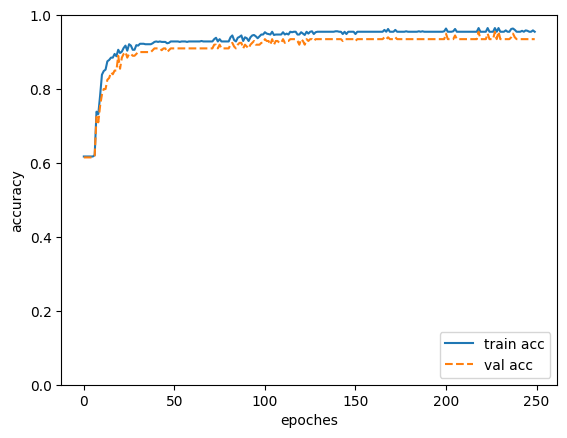

In [24]:
import matplotlib.pyplot as plt

markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, val_acc_list, label='val acc', linestyle='--')
plt.xlabel("epoches")
plt.ylabel('accuracy')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


# 課題提出

In [25]:
# テストデータ生成
X_test = pd.read_csv('titanic_test_x.csv', index_col=0)
X_test = X_test.replace('?', np.nan)

# データクレンジング
X_test = X_test[['pclass', 'age', 'sex', 'sibsp', 'embarked', 'boat']]

# ageの抜けは平均値で埋める
X_test['age'] = X_test['age'].astype(float)
X_test['age'] = X_test['age'].fillna(ave_age).fillna(ave_age).astype(int)

# 性別エンコーディング
X_test['sex'] = X_test['sex'].map( {'female': 1, 'male': 0} ).astype(int)

# embarkedエンコーディング
X_test['embarked'] = X_test['embarked'].fillna(freq_port)
X_test['embarked'] = X_test['embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

# boatをエンコーディング
X_test['boat'] = X_test['boat'].map(boat_map).fillna(-1).astype(int)

# 予測
y_pred = network.predict(X_test)
y_pred = np.where(y_pred >= 0.5, 1, 0)
y_pred = pd.DataFrame(y_pred, columns=['survived'])

# csv形式で提出する。
y_pred.to_csv('y_pred.csv')
y_pred

,survived
0,1
1,0
2,0
3,0
4,1
...,...
304,0
305,0
306,1
307,1
